<a href="https://colab.research.google.com/github/Antonyus1204/Proyecto_grupal_BIO218/blob/main/Proyecto_grupal_BIO218(version2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Grupal Colaborativo — BIO 218
## TEMA

**Integrantes:** Castillo Jamel Alejandra, Castillo Ashly Marieth, De Gracia Yahelys, Donoso David Antonio, Gill Liz Denis, Castillo Francia.

## Problema biológico


## Pregunta de investigación
¿?

## Hipótesis
- **H₁:**
- **H₀:**

## Variables

| Variable | Tipo | Unidad | Papel |
|---|---|---|---|
| - | - | - | - |
| - | - | - | - |
| - | - | - | - |
| - | - | - | - |

---
### Importación de librerías

In [1]:
# -------------------------------------------------------------
# CELDA 1. IMPORTACIÓN DE LIBRERÍAS (A)
# -------------------------------------------------------------
# NumPy permite generar números aleatorios con distribuciones estadísticas
# (como la normal) y hacer cálculos numéricos sobre conjuntos de datos completos.
import numpy as np

# Pandas se utiliza para organizar los datos en un DataFrame.
import pandas as pd

# Matplotlib se utiliza para construir visualizaciones científicas.
import matplotlib.pyplot as plt

# Seaborn se utiliza para visualización estadística.
import seaborn as sns

# Definimos el estilo visual de todos los gráficos: fondo blanco con cuadrícula gris.
sns.set_theme(style="whitegrid")

# Confirmamos que el entorno quedó preparado.
print("Entorno de análisis preparado correctamente.")

Entorno de análisis preparado correctamente.



## Carga del CSV en Google Colab



In [2]:
# ------------------------------------------------------------
# CELDA 2. CARGA DIRECTA CON pd.read_csv() (A)
# ------------------------------------------------------------

# Colocamos la ruta en la que se encuentra nuestro
ruta_archivo = "/content/G6_Hipoxia_Expresion_Genica.csv"
df = pd.read_csv(ruta_archivo)

# Mensaje de verificación
print("Base cargada correctamente.")

# Mensajes de verificación
print("Dimensiones:", df.shape)

# df.head nos muestra Primeras 5 filas del csv
df.head()

Base cargada correctamente.
Dimensiones: (122, 7)


,id_muestra,condicion_oxigeno,replica,expresion_relativa,Ct_target,Ct_housekeeping,viabilidad_pct
0,GX001,Normoxia,1,3.910274,19.390742,21.583071,92.929389
1,GX002,Normoxia,2,2.842201,17.003781,19.459154,94.375605
2,GX003,Normoxia,3,1.454097,19.486390,20.752916,95.072846
3,GX004,Normoxia,4,1.723650,20.282704,21.156500,94.576268
4,GX005,Normoxia,5,2.104237,20.000665,21.078251,91.631589


## Primera inspección del dataset

Revisamos la estructura general (`head`, `info`) y el resumen estadístico
(`describe`) para confirmar que el dataset se generó correctamente, sin
valores faltantes y con variación realista entre observaciones.

In [3]:
# -------------------------------------------------------------
# CELDA 3. PRIMERA INSPECCIÓN DEL DATASET (A)
# -------------------------------------------------------------
# head() muestra las primeras cinco observaciones.
display(df.head())

# info() resume tipos de datos y valores no nulos.
df.info()

# describe() genera un resumen de las variables numéricas utilizando 2 decimales.
display(df.describe().round(2))

,id_muestra,condicion_oxigeno,replica,expresion_relativa,Ct_target,Ct_housekeeping,viabilidad_pct
0,GX001,Normoxia,1,3.910274,19.390742,21.583071,92.929389
1,GX002,Normoxia,2,2.842201,17.003781,19.459154,94.375605
2,GX003,Normoxia,3,1.454097,19.486390,20.752916,95.072846
3,GX004,Normoxia,4,1.723650,20.282704,21.156500,94.576268
4,GX005,Normoxia,5,2.104237,20.000665,21.078251,91.631589


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_muestra          122 non-null    object 
 1   condicion_oxigeno   122 non-null    object 
 2   replica             122 non-null    int64  
 3   expresion_relativa  121 non-null    float64
 4   Ct_target           122 non-null    float64
 5   Ct_housekeeping     122 non-null    float64
 6   viabilidad_pct      122 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 6.8+ KB


,replica,expresion_relativa,Ct_target,Ct_housekeeping,viabilidad_pct
count,122.00,121.00,122.00,122.00,122.00
mean,20.34,7.88,17.79,20.72,86.34
std,11.62,8.20,1.47,3.20,9.98
min,1.00,-3.00,14.25,18.96,65.81
25%,10.25,2.19,16.73,19.98,77.56
50%,20.00,4.37,17.86,20.40,88.36
75%,30.00,12.67,19.02,20.95,93.61
max,40.00,38.74,21.08,55.00,130.00


% de valores ausentes

In [4]:
# -------------------------------------------------------------
# CELDA 4. VERIFICACIÓN Y TRATAMIENTO DE DUPLICADOS Y LIMPIEZA (Jamel)
# -------------------------------------------------------------

# 1. Crear una copia de trabajo limpia
df_limpio = df.copy()

# 2. Corregir formato y espacios en 'condicion_oxigeno'
df_limpio['condicion_oxigeno'] = df_limpio['condicion_oxigeno'].astype(str).str.strip().str.capitalize()

# 3. Contar y revisar duplicados
duplicados_totales = df_limpio.duplicated().sum()
duplicados_id = df_limpio.duplicated(subset=['id_muestra']).sum()

print(f"Filas completamente duplicadas: {duplicados_totales}")
print(f"Muestras con 'id_muestra' duplicado: {duplicados_id}")

# 4. Eliminar duplicados si los hubiera
df_limpio = df_limpio.drop_duplicates(subset=['id_muestra'], keep='first').reset_index(drop=True)

# 5. Imputar el valor ausente en 'expresion_relativa' con la mediana por grupo
mediana_grupo = df_limpio.groupby('condicion_oxigeno')['expresion_relativa'].transform('median')
df_limpio['expresion_relativa'] = df_limpio['expresion_relativa'].fillna(mediana_grupo)

print("\n--- Verificación post-limpieza ---")
print("Dimensiones resultantes:", df_limpio.shape)
print("Categorías de oxígeno:", df_limpio['condicion_oxigeno'].unique())
print("Valores ausentes pendientes:", df_limpio.isna().sum().sum())

Filas completamente duplicadas: 2
Muestras con 'id_muestra' duplicado: 2

--- Verificación post-limpieza ---
Dimensiones resultantes: (120, 7)
Categorías de oxígeno: ['Normoxia' 'Hipoxia' 'Recuperación' 'Recuperacion']
Valores ausentes pendientes: 0


Verificación visual

/tmp/ipykernel_1488/1373123087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x="condicion_oxigeno", y="expresion_relativa", palette="Set2")


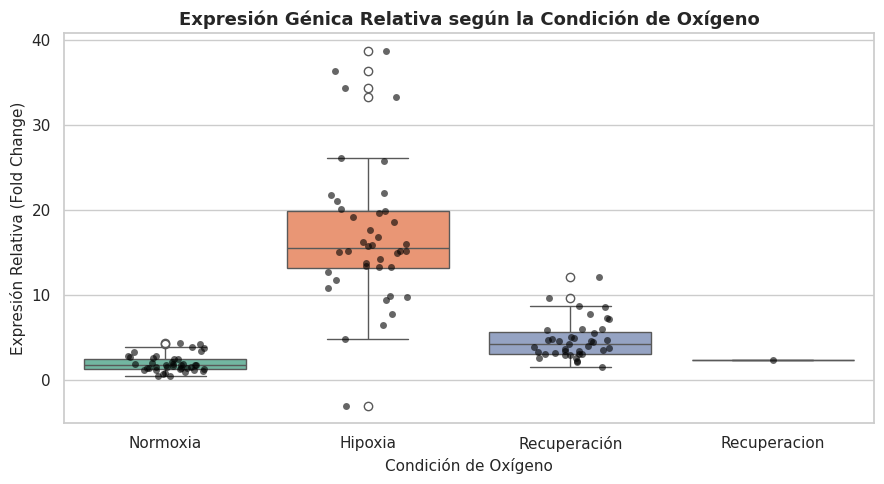

In [5]:
# -------------------------------------------------------------
# CELDA 5. GRÁFICO BOXPLOT CORREGIDO (Jamel)
# -------------------------------------------------------------
plt.figure(figsize=(9, 5))

sns.boxplot(data=df_limpio, x="condicion_oxigeno", y="expresion_relativa", palette="Set2")
sns.stripplot(data=df_limpio, x="condicion_oxigeno", y="expresion_relativa", alpha=0.6, color="black", jitter=0.2)

plt.title("Expresión Génica Relativa según la Condición de Oxígeno", fontsize=13, fontweight='bold')
plt.xlabel("Condición de Oxígeno", fontsize=11)
plt.ylabel("Expresión Relativa (Fold Change)", fontsize=11)
plt.tight_layout()
plt.show()

## Estrategia preliminar de análisis

**1. ¿Cuál es nuestra pregunta?**


**2. Variable dependiente:**

**3. Variable independiente:**

**4. Tipo de variables:**

**5. Grupos comparados:**

**6. Supuestos verificados:**


**7. Método seleccionado:**
